# Part 2


Imports

In [3]:
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

Settings

In [4]:
SEED = 42
DATA_PATH = r"dataset/jigsaw-unintended-bias-train.csv"

# IMPORTANT:
# Keep these exactly same as Part 1
TRAIN_SIZE = 10_000
EVAL_SIZE = 2_000

random.seed(SEED)
np.random.seed(SEED)

Load main dataset

In [6]:
df = pd.read_csv(
    DATA_PATH,
    usecols=[
        "comment_text",
        "toxic",
        "black",
        "white",
        "muslim",
        "jewish",
        "homosexual_gay_or_lesbian"
    ]
)

df = df.dropna(subset=["comment_text", "toxic"]).copy()
df["label"] = (df["toxic"] >= 0.5).astype(int)

print("Dataset shape:", df.shape)
print(df.head())

Dataset shape: (1902191, 8)
                                        comment_text     toxic  black  \
0  This is so cool. It's like, 'would you want yo...  0.000000    NaN   
1  Thank you!! This would make my life a lot less...  0.000000    NaN   
2  This is such an urgent design problem; kudos t...  0.000000    NaN   
3  Is this something I'll be able to install on m...  0.000000    NaN   
4               haha you guys are a bunch of losers.  0.893617    0.0   

   homosexual_gay_or_lesbian  jewish  muslim  white  label  
0                        NaN     NaN     NaN    NaN      0  
1                        NaN     NaN     NaN    NaN      0  
2                        NaN     NaN     NaN    NaN      0  
3                        NaN     NaN     NaN    NaN      0  
4                        0.0     0.0     0.0    0.0      1  


train/eval split

In [7]:
sample_total = TRAIN_SIZE + EVAL_SIZE

sampled_df, _ = train_test_split(
    df,
    train_size=sample_total,
    stratify=df["label"],
    random_state=SEED
)

train_df, eval_df = train_test_split(
    sampled_df,
    train_size=TRAIN_SIZE,
    test_size=EVAL_SIZE,
    stratify=sampled_df["label"],
    random_state=SEED
)

train_df = train_df.reset_index(drop=True)
eval_df = eval_df.reset_index(drop=True)

print("Train shape:", train_df.shape)
print("Eval shape :", eval_df.shape)
print("\nEval label distribution:")
print(eval_df["label"].value_counts(normalize=True))

Train shape: (10000, 8)
Eval shape : (2000, 8)

Eval label distribution:
label
0    0.92
1    0.08
Name: proportion, dtype: float64


Load Part 1 outputs

In [8]:
y_prob = np.load("saved_models/part1_eval_probs.npy")
y_true = np.load("saved_models/part1_eval_labels.npy")

with open("saved_models/part1_config.json", "r") as f:
    config = json.load(f)

BEST_THRESHOLD = config["best_threshold"]

print("Loaded threshold:", BEST_THRESHOLD)
print("y_prob shape:", y_prob.shape)
print("y_true shape:", y_true.shape)
print("eval_df shape:", eval_df.shape)

Loaded threshold: 0.3
y_prob shape: (2000,)
y_true shape: (2000,)
eval_df shape: (2000, 8)


predictions to eval subset

In [9]:

if len(eval_df) != len(y_true):
    raise ValueError(
        f"Mismatch: eval_df has {len(eval_df)} rows but y_true has {len(y_true)} rows. "
        "Make sure TRAIN_SIZE and EVAL_SIZE match Part 1 exactly."
    )

eval_df = eval_df.copy()
eval_df["y_true"] = y_true
eval_df["y_prob"] = y_prob
eval_df["y_pred"] = (eval_df["y_prob"] >= BEST_THRESHOLD).astype(int)

eval_df.head()

,comment_text,toxic,black,homosexual_gay_or_lesbian,jewish,muslim,white,label,y_true,y_prob,y_pred
0,Your point is well taken Danno!\n\nIt's intere...,0.400000,NaN,NaN,NaN,NaN,NaN,0,0,0.004654,0
1,"But if the only witness is the victim, what then?",0.000000,NaN,NaN,NaN,NaN,NaN,0,0,0.006027,0
2,"Fascinating work, not so much the attack on Br...",0.166667,NaN,NaN,NaN,NaN,NaN,0,0,0.005367,0
3,"All taxes, except those that you do not pay, a...",0.000000,NaN,NaN,NaN,NaN,NaN,0,0,0.002821,0
4,Sorry to say Mr. Brule it is Obama who has pla...,1.000000,NaN,NaN,NaN,NaN,NaN,1,1,0.095400,0


Construct bias audit cohorts

In [10]:
high_black = eval_df[eval_df["black"] >= 0.5].copy()
reference = eval_df[(eval_df["black"] < 0.1) & (eval_df["white"] >= 0.5)].copy()

print("High-black cohort size:", len(high_black))
print("Reference cohort size :", len(reference))

High-black cohort size: 13
Reference cohort size : 14


Helper function for metrics

In [11]:
def compute_group_metrics(df_group):
    y_t = df_group["y_true"].values
    y_p = df_group["y_pred"].values

    cm = confusion_matrix(y_t, y_p, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    tpr = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    fnr = fn / (fn + tp) if (fn + tp) > 0 else 0.0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    positive_prediction_rate = (y_p == 1).mean() if len(y_p) > 0 else 0.0

    return {
        "TPR": tpr,
        "FPR": fpr,
        "FNR": fnr,
        "Precision": precision,
        "PositivePredictionRate": positive_prediction_rate,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp
    }

Compute metrics for both cohorts

In [12]:

hb_metrics = compute_group_metrics(high_black)
ref_metrics = compute_group_metrics(reference)

summary_table = pd.DataFrame(
    [hb_metrics, ref_metrics],
    index=["High-Black", "Reference"]
)

summary_table

,TPR,FPR,FNR,Precision,PositivePredictionRate,TN,FP,FN,TP
High-Black,0.25,0.111111,0.75,0.5,0.153846,8,1,3,1
Reference,0.00,0.000000,1.00,0.0,0.000000,12,0,2,0


Fairness metrics

In [13]:
disparate_impact_ratio = (
    hb_metrics["FPR"] / ref_metrics["FPR"]
    if ref_metrics["FPR"] > 0 else np.nan
)

statistical_parity_difference = (
    hb_metrics["PositivePredictionRate"] - ref_metrics["PositivePredictionRate"]
)

equal_opportunity_difference = (
    hb_metrics["TPR"] - ref_metrics["TPR"]
)

print("Disparate Impact Ratio:", disparate_impact_ratio)
print("Statistical Parity Difference:", statistical_parity_difference)
print("Equal Opportunity Difference:", equal_opportunity_difference)

Disparate Impact Ratio: nan
Statistical Parity Difference: 0.15384615384615385
Equal Opportunity Difference: 0.25


summary table for report

In [14]:
results_table = pd.DataFrame({
    "Cohort": ["High-Black", "Reference"],
    "TPR": [hb_metrics["TPR"], ref_metrics["TPR"]],
    "FPR": [hb_metrics["FPR"], ref_metrics["FPR"]],
    "FNR": [hb_metrics["FNR"], ref_metrics["FNR"]],
    "Precision": [hb_metrics["Precision"], ref_metrics["Precision"]],
    "PositivePredictionRate": [
        hb_metrics["PositivePredictionRate"],
        ref_metrics["PositivePredictionRate"]
    ]
})

results_table

,Cohort,TPR,FPR,FNR,Precision,PositivePredictionRate
0,High-Black,0.25,0.111111,0.75,0.5,0.153846
1,Reference,0.00,0.000000,1.00,0.0,0.000000


Grouped bar chart

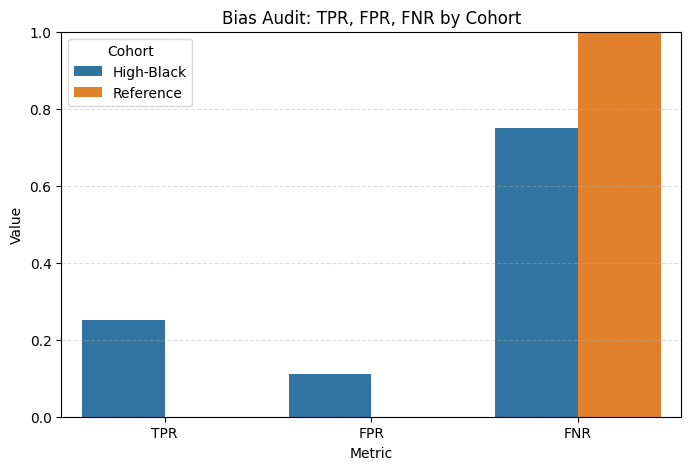

In [15]:
plot_df = pd.DataFrame({
    "Metric": ["TPR", "FPR", "FNR"],
    "High-Black": [hb_metrics["TPR"], hb_metrics["FPR"], hb_metrics["FNR"]],
    "Reference": [ref_metrics["TPR"], ref_metrics["FPR"], ref_metrics["FNR"]]
})

plot_df = plot_df.melt(id_vars="Metric", var_name="Cohort", value_name="Value")

plt.figure(figsize=(8, 5))
sns.barplot(data=plot_df, x="Metric", y="Value", hue="Cohort")
plt.title("Bias Audit: TPR, FPR, FNR by Cohort")
plt.ylim(0, 1)
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.show()

Confusion matrix helper

In [16]:
def plot_confusion_for_group(df_group, title):
    cm = confusion_matrix(df_group["y_true"], df_group["y_pred"], labels=[0, 1])
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

Two confusion matrices

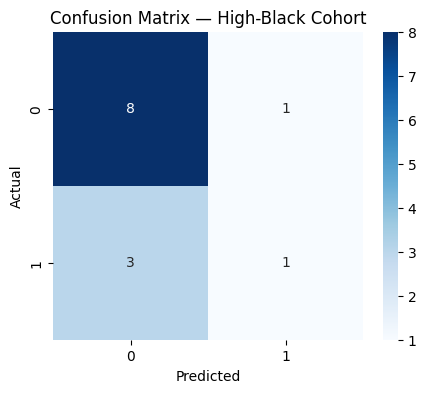

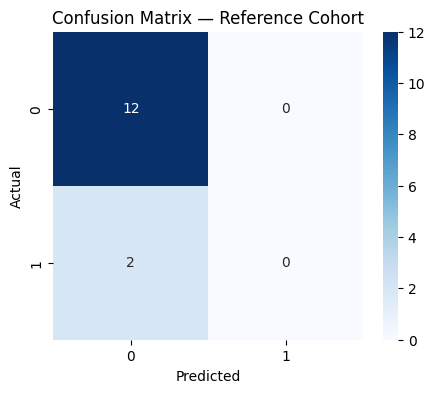

In [17]:
plot_confusion_for_group(high_black, "Confusion Matrix — High-Black Cohort")
plot_confusion_for_group(reference, "Confusion Matrix — Reference Cohort")

Quick interpretation

In [18]:
print("Quick interpretation:\n")

if hb_metrics["FPR"] > ref_metrics["FPR"]:
    print("- The model over-flags the High-Black cohort more than the Reference cohort.")
else:
    print("- The model does not over-flag the High-Black cohort based on FPR.")

if hb_metrics["FNR"] > ref_metrics["FNR"]:
    print("- The model misses more toxic comments in the High-Black cohort.")
else:
    print("- The model does not miss more toxic comments in the High-Black cohort based on FNR.")

gaps = {
    "TPR gap": abs(hb_metrics["TPR"] - ref_metrics["TPR"]),
    "FPR gap": abs(hb_metrics["FPR"] - ref_metrics["FPR"]),
    "FNR gap": abs(hb_metrics["FNR"] - ref_metrics["FNR"])
}

largest_gap = max(gaps, key=gaps.get)
print(f"- Largest disparity: {largest_gap}")

Quick interpretation:

- The model over-flags the High-Black cohort more than the Reference cohort.
- The model does not miss more toxic comments in the High-Black cohort based on FNR.
- Largest disparity: TPR gap


Save Part 2 outputs

In [19]:
results_table.to_csv("saved_models/part2_bias_results.csv", index=False)

with open("saved_models/part2_fairness_metrics.json", "w") as f:
    json.dump({
        "high_black_size": int(len(high_black)),
        "reference_size": int(len(reference)),
        "disparate_impact_ratio": None if np.isnan(disparate_impact_ratio) else float(disparate_impact_ratio),
        "statistical_parity_difference": float(statistical_parity_difference),
        "equal_opportunity_difference": float(equal_opportunity_difference)
    }, f, indent=2)

print("Saved:")
print(" - saved_models/part2_bias_results.csv")
print(" - saved_models/part2_fairness_metrics.json")

Saved:
 - saved_models/part2_bias_results.csv
 - saved_models/part2_fairness_metrics.json
